# Blood Rheology: Mt-ETV (Langmuir) Model Analysis and Visualization

## Overview
The **Modified thermodynamic Extended Thixotropic Vector (Mt-ETV) model** is a thermodynamically
consistent generalization of Beris's t-ETV model, derived from a single Helmholtz free energy
$\hat{f}_c$ rather than postulated empirically. It describes blood behavior using three structural
variables:

1. **Cellular conformation tensor** ($\mathbf{c}^C$): describes the deformation and orientation of
   individual red blood cells.
2. **Rouleaux conformation tensor** ($\mathbf{c}^R$): describes the deformation and orientation of
   cell aggregates (rouleaux formations).
3. **Structure parameter** ($\lambda$): quantifies the degree of aggregation, ranging from 0 (fully
   dispersed) to 1 (fully aggregated).

The key modification with respect to t-ETV is the coupling between $\lambda$ and $\mathbf{c}^R$: instead
of an empirically postulated deformation-activation term, the coupling function $\varphi(\zeta)$ 
(with $\zeta = \lambda e^{D_R}$, $D_R = \text{tr}(\mathbf{c}^R)-\log|\mathbf{c}^R|-3$) is fixed by a **Langmuir
adsorption isotherm**, motivated by the microscopic picture of fibrinogen-mediated cell-cell bridging:

$$
\varphi'(\zeta) = \frac{(\zeta_c+1)\,\zeta}{\zeta_c+\zeta}, \qquad
\varphi(\zeta) = (\zeta_c+1)\left[\zeta-\zeta_c\log\!\left(1+\frac{\zeta}{\zeta_c}\right)\right].
$$

This introduces a single new free-energy parameter $\zeta_c$ (constrained to $\zeta_c>(m-1)/(2-m)$
for admissibility and stability), and a deformation-activated Onsager mobility for $\lambda$,

$$
M(\lambda,D_R)=\frac{1}{\tau_\lambda}\lambda^{1-m}(1-\lambda)\left[1+(bD_R)^{d/2}\right],
$$

which reduces to the empirical t-ETV activation term $|\tau_{\rm aggr}\dot\gamma|^d$ in the weak-flow
limit, with $\tau_{\rm aggr}=\sqrt{b}\,\tau_R$.

## Workflow
In the following cells, we will: (1) derive and symbolically construct the Mt-ETV (Langmuir) model
equations using SymPy, (2) lambdify the equations to obtain efficient numerical functions, (3) solve
the resulting differential equations via time integration for startup flow, flow cessation, and shear
reversal, and (4) generate comprehensive visualizations and store the results for multiple shear rates
to characterize the model's predictions, for later comparison against t-ETV.

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from extras import show 

sp.init_printing()

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}\usepackage{amsmath}"
})

## 1. Symbolic Construction

We define the symbolic variables that will be used throughout the model:

- **Independent variable**: time $t$
- **Imposed shear rate**: $\dot{\gamma}_0$ (constant for simple shear flow startup)
- **State variables**: components of the conformation tensors ($c^C_{ij}$, $c^R_{ij}$) and the structure parameter ($\lambda$) — unchanged from t-ETV, since the state space of Mt-ETV is the same
- **Model parameters**: material constants governing viscosity, elasticity, and structural evolution

The **cellular sector** parameters are identical to t-ETV, since the cellular free energy and stress
were already thermodynamically consistent in Boris's model and are untouched by the Langmuir
modification. The **rouleaux/structural sector** changes: we replace the empirical t-ETV kinetics
constants ($\tau_{break}$, $\tau_{aggr}$) with the parameters that actually enter the Mt-ETV free
energy and mobility — the Langmuir dissociation constant $\zeta_c$, the structural mobility timescale
$\tau_\lambda$, the rouleaux relaxation time $\tau_R$, and the deformation-activation constants $b,d$.
Recall $\tau_{aggr}=\sqrt{b}\,\tau_R$ is *derived*, not independently fitted.

In [2]:
# --- independent variable and imposed shear rate ---
t = sp.symbols('t', real=True)
gamma0 = sp.symbols(r'\dot{\gamma_0}', real=True)   # dot(gamma)_0, constant (simple shear startup)

# --- state: components of conformation tensors + lambda ---
cCxx, cCxy, cCyy, cCzz = sp.symbols(r'c^C_{xx} c^C_{xy} c^C_{yy} c^C_{zz}', real=True)
cRxx, cRxy, cRyy, cRzz = sp.symbols(r'c^R_{xx} c^R_{xy} c^R_{yy} c^R_{zz}', real=True)
lam = sp.symbols(r'\lambda', positive=True)

state_syms = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam)

# --- model parameters ---
# Cellular sector: unchanged from t-ETV (Carreau-type shear-thinning solvent viscosity eta(gammadot))
G_C, muC0, muCinf, tauC = sp.symbols(r'G_C \mu_{0-c} \mu_{\infty-C} \tau_C', positive=True)

# Rouleaux / structural sector: replaced by the Langmuir free-energy and Onsager-mobility parameters
G_R, tau_R                 = sp.symbols(r'G_R \tau_R', positive=True)          # rouleaux modulus, constant relaxation time
m, zeta_c                  = sp.symbols(r'm \zeta_c', positive=True)           # stress exponent, Langmuir dissociation constant
tau_lam, b_kin, dexp       = sp.symbols(r'\tau_\lambda b d', positive=True)    # mobility timescale, activation constants

rho, Temp = sp.symbols('rho T', positive=True)

param_syms = (G_C, muC0, muCinf, tauC, G_R, tau_R, m, zeta_c, tau_lam, b_kin, dexp, rho, Temp)

### Cellular Viscosity (Cross-like Model)

The cellular contribution to the viscosity is **unchanged from the t-ETV model**: the thermodynamic derivation only modifies the constitutive relations tied to $\hat{f}_c$ (the rouleaux stress, the relaxation functions, and the structural evolution of $\lambda$), while the cellular viscosity remains an independently specified shear-rate-dependent (shear-thinning) closure:

$$\eta_C(\dot{\gamma}_0) = \mu_{C,\infty} + \frac{\mu_{C,0} - \mu_{C,\infty}}{1 + \tau_C \dot{\gamma}_0}$$

where $\mu_{C,0}$ is the zero-shear viscosity, $\mu_{C,\infty}$ is the infinite-shear viscosity, and $\tau_C$ is the relaxation time.

In [3]:
# Viscosity non-linear (Cross-like) for individual cellular contribution
# Identical closure to the t-ETV model: this term is not derived from the
# free energy and carries over unchanged into the Mt-ETV formulation.
eta_C = muCinf + (muC0 - muCinf)/(1 + tauC*gamma0)

show(eta_C)

<IPython.core.display.Math object>

## Complete Evolution Equations (Kinematic + Relaxation)

The kinematics are identical to the t-ETV model: same simple shear flow, same velocity gradient
$\nabla\vec{v}$, same block-diagonal structure for $\mathbf{c}^C$ and $\mathbf{c}^R$, and the same
kinematic (upper-convected) contribution to each component. We reuse the state symbols already
defined above rather than redefining a second set of tensor-component symbols.

The relaxation terms:

- **Cellular tensor**: unchanged from t-ETV — $\dot{\mathbf{c}}^C_{\rm relax} = \dfrac{G_C}{\eta_C(\dot\gamma_0)}(\boldsymbol{\delta}-\mathbf{c}^C)$, since this closure does not depend on the free energy.
- **Rouleaux tensor**: the Langmuir model keeps **Boris's original constant-relaxation-time ansatz**,
$$\dot{\mathbf{c}}^R_{\rm relax} = \frac{1}{\tau_R}(\boldsymbol{\delta}-\mathbf{c}^R).$$
Unlike the earlier logarithmic-$\Phi$ notebook, the admissibility analysis for the Langmuir model is carried out directly with this constant form (see the derivation of condition (A1)), so no free-energy-consistent $\mathbf{c}^R$ relaxation is needed here. The free-energy machinery ($D_R$, $\zeta$, $\varphi(\zeta)$, $\zeta_c$) is introduced later, where it actually enters the model: the $\lambda$ evolution equation and the stress/entropy expressions.

In [4]:
# ============================================================
# Simple shear flow kinematics (identical to t-ETV)
# ============================================================
nabla_v = sp.Matrix([
    [0, gamma0, 0],
    [0, 0, 0],
    [0, 0, 0]
])
delta = sp.eye(3)

# Conformation tensors, built from the state symbols already defined above
# (no duplicate symbol set)
cC = sp.Matrix([[cCxx, cCxy, 0], [cCxy, cCyy, 0], [0, 0, cCzz]])
cR = sp.Matrix([[cRxx, cRxy, 0], [cRxy, cRyy, 0], [0, 0, cRzz]])

# Upper-convected kinematic contribution: (grad v)^T . c + c . grad v
upper_conv_C = nabla_v.T @ cC + cC @ nabla_v
upper_conv_R = nabla_v.T @ cR + cR @ nabla_v

# ============================================================
# Cellular relaxation: unchanged from t-ETV (no free-energy dependence)
# ============================================================
relaxC_coef = G_C / eta_C
cC_relax = relaxC_coef * (delta - cC)

dc11C = upper_conv_C[0, 0] + cC_relax[0, 0]
dc12C = upper_conv_C[0, 1] + cC_relax[0, 1]
dc22C = upper_conv_C[1, 1] + cC_relax[1, 1]
dc33C = upper_conv_C[2, 2] + cC_relax[2, 2]

# ============================================================
# Rouleaux relaxation: Boris's original constant-relaxation-time ansatz
# (retained as-is by the Langmuir model; no free-energy dependence here)
# ============================================================
relaxR_coef = 1 / tau_R
cR_relax = relaxR_coef * (delta - cR)

dc11R = upper_conv_R[0, 0] + cR_relax[0, 0]
dc12R = upper_conv_R[0, 1] + cR_relax[0, 1]
dc22R = upper_conv_R[1, 1] + cR_relax[1, 1]
dc33R = upper_conv_R[2, 2] + cR_relax[2, 2]

print("Cellular tensor evolution (unchanged from t-ETV):")
show(dc11C); show(dc12C); show(dc22C); show(dc33C)

print("\nRouleaux tensor evolution (Boris constant relaxation):")
show(dc11R); show(dc12R); show(dc22R); show(dc33R)

Cellular tensor evolution (unchanged from t-ETV):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Rouleaux tensor evolution (Boris constant relaxation):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Structural Evolution Equation

The structure parameter $\lambda$ follows from the Helmholtz free energy through the kinematic
coupling tensor and a deformation-activated Onsager relaxation:

$$\frac{d\lambda}{dt} = \underbrace{-2\lambda\dot{\gamma}_0 c_{12}^R}_{\mathbf{g}:\dot{\boldsymbol\gamma},\ \ \mathbf{g}=-\lambda(\mathbf{c}^R-\boldsymbol\delta)} \;+\; \underbrace{-M(\lambda,D_R)\,\frac{\partial\hat{f}_c}{\partial\lambda}}_{\dot\lambda_{\rm relax}}$$

with the Langmuir free energy $\hat f_c(\lambda,D_R) = -\dfrac{G_R}{2m\rho}\lambda^m + \dfrac{G_R}{2\rho}\varphi(\zeta)$, $\zeta=\lambda e^{D_R}$, $\varphi(\zeta)=(\zeta_c+1)\left[\zeta-\zeta_c\log(1+\zeta/\zeta_c)\right]$, and the degenerate, deformation-activated mobility

$$M(\lambda,D_R) = \frac{2\rho}{G_R\tau_\lambda}\,\lambda^{1-m}(1-\lambda)\left[1+(b\,D_R)^{d/2}\right].$$

Two things differ from the earlier Propuesta-3 notebook:

- **No equilibrium condition to solve numerically.** Unlike the logarithmic ansatz, the Langmuir
  coefficient $A=\zeta_c+1$ is fixed *analytically* by (A3), so there is no `sp.solve` call here —
  $\zeta_c$ itself remains the one free parameter.
- **Deformation activation.** $M$ now depends on $D_R$ through the factor $[1+(bD_R)^{d/2}]$, which
  is what reproduces the empirical t-ETV activation term $|\tau_{\rm aggr}\dot\gamma|^d$ asymptotically
  (with $\tau_{\rm aggr}=\sqrt{b}\,\tau_R$); the constant-mobility form used before had no such term.

As before, $\tau_R$ does not appear here — it already entered as a constant in the rouleaux
relaxation function defined in the previous cell.

In [6]:
# Rouleaux deformation invariant D_R = tr(c^R) - log|c^R| - 3  (>=0, zero at rest, D_R = -(I_R+3))
D_R = sp.trace(cR) - sp.log(cR.det()) - 3

# zeta = lambda * exp(D_R); Langmuir coupling phi(zeta), with A = zeta_c + 1 fixed
# analytically by (A3) -- no equilibrium solve needed here (unlike Propuesta 3's 'a').
zeta = lam * sp.exp(D_R)
A_langmuir = zeta_c + 1
phi = A_langmuir * (zeta - zeta_c*sp.log(1 + zeta/zeta_c))
Phi = (G_R / (2*rho)) * phi

f_c_lam_IR = -(G_R / (2*m*rho)) * lam**m + Phi

# Degenerate, deformation-activated Onsager mobility: vanishes at lambda=0,1,
# and is boosted by shear-induced rouleaux deformation via [1+(b*D_R)^(d/2)]
M_lam = (2*rho / (G_R*tau_lam)) * lam**(1 - m) * (1 - lam) * (1 + (b_kin*D_R)**(dexp/2))

dfc_dlam = sp.diff(f_c_lam_IR, lam)
dlam_relax = sp.simplify(-M_lam * dfc_dlam)
dlam_kin = -2*lam*gamma0*cRxy
dlam_dt = dlam_kin + dlam_relax

show(dlam_dt)

<IPython.core.display.Math object>

### Stress Tensor Components

The shear stress is composed of viscous and elastic contributions:

$$\tau_{xy} = \tau^C_{xy} + \tau^R_{xy}$$

where:
$$\tau^C_{xy} = -\eta_C(\dot{\gamma}_0) \dot{\gamma}_0 - G_C c^C_{xy}$$
$$\tau^R_{xy} = -G_R \lambda^m c^R_{xy}$$

This is **exactly Boris's stress relation**, unchanged from t-ETV. As shown in the derivation, the
constitutive relation for $\tau^R$ is recovered for *any* differentiable coupling function $\varphi$ —
the Langmuir choice affects only the relaxation kinetics ($\dot\lambda$, $\dot{\mathbf c}^R$) and the
entropy generation, never the stress formula itself.

In [7]:
# Stress components - using the state symbols defined earlier (cCxy, cRxy)
# Formula is identical to t-ETV: the stress-energy relation holds for any
# differentiable phi, so the Langmuir choice of phi has no effect here.
tau_xy_C = -eta_C*gamma0 - G_C*cCxy
tau_xy_R = -G_R*lam**m*cRxy
tau_xy   = tau_xy_C + tau_xy_R

show(tau_xy)

<IPython.core.display.Math object>

### Entropy Generation Rate (Mt-ETV, Langmuir Coupling)

The cellular contribution is **unchanged from t-ETV** (independent of $\varphi$):

$$\sigma_c^C = \frac{\partial\hat{f}_c}{\partial c^C} : \dot{c}^C_{\text{relax}}\Big/(-T) = \frac{G_C^2}{2\eta_C(\dot{\gamma})\rho T} \left( \text{tr}\left[(\mathbf{c}^C)^{-1}\right] + \text{tr}(\mathbf{c}^C) - 6 \right)$$

For the rouleaux contribution, the derivation in the document (second inequality, Boris's constant $1/\tau_R$ relaxation) gives a coefficient $\zeta\varphi'(\zeta)$ in place of t-ETV's $\lambda^m$:

$$\sigma_c^R = \frac{G_R\,\zeta\varphi'(\zeta)}{2\tau_R\,\rho T}\left(\text{tr}\left[(\mathbf{c}^R)^{-1}\right]+\text{tr}(\mathbf{c}^R)-6\right), \qquad \zeta\varphi'(\zeta) = \frac{(\zeta_c+1)\,\zeta^2}{\zeta_c+\zeta}$$

For the structural contribution, rather than hand-deriving a closed formula (as t-ETV's markdown does), we use the fact that we already computed $\partial\hat f_c/\partial\lambda$ (`dfc_dlam`) and $\dot\lambda_{\rm relax}$ (`dlam_relax`) symbolically in the previous cell, so

$$\sigma_\lambda = -\frac{1}{T}\frac{\partial\hat f_c}{\partial\lambda}\,\dot\lambda_{\rm relax} = \frac{M(\lambda,D_R)}{T}\left(\frac{\partial\hat f_c}{\partial\lambda}\right)^2 \geq 0$$

is obtained directly by reusing those two expressions — no separate mobility formula needs to be re-typed, avoiding any inconsistency with the ODE actually being integrated.

The total entropy generation is: $S_{\text{gen}} = \rho T (\sigma_c^C + \sigma_c^R + \sigma_\lambda)$

In [10]:
# Reusing the correctly-named state symbols from earlier cells (no duplicate
# symbol set): cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz

# --- Cellular sector: unchanged from t-ETV ---
trC = cCxx + cCyy + cCzz
cC2 = sp.Matrix([[cCxx, cCxy], [cCxy, cCyy]])
trinvC = sp.simplify(cC2.inv().trace() + 1/cCzz)

term1 = (G_C**2 / (2*eta_C*rho*Temp)) * (trinvC + trC - 6)

# --- Rouleaux sector: coefficient is zeta*phi'(zeta), not lambda^m as in t-ETV ---
trR = cRxx + cRyy + cRzz
cR2 = sp.Matrix([[cRxx, cRxy], [cRxy, cRyy]])
trinvR = sp.simplify(cR2.inv().trace() + 1/cRzz)

# phi'(zeta) obtained by symbolic differentiation on an abstract argument,
# then substituting the actual zeta expression (avoids hand-derived chain rule)
zeta_symbol = sp.symbols('zeta', positive=True)
phi_of_zeta = A_langmuir * (zeta_symbol - zeta_c*sp.log(1 + zeta_symbol/zeta_c))
phi_prime = sp.diff(phi_of_zeta, zeta_symbol).subs(zeta_symbol, zeta)

term2 = (G_R * zeta * phi_prime / (2*tau_R*rho*Temp)) * (trinvR + trR - 6)

# --- Structural (lambda) sector: reuse dfc_dlam and dlam_relax from the
# previous cell instead of re-deriving a closed-form expression by hand ---
term3 = -dfc_dlam * dlam_relax / Temp

Sgen = term1 + term2 + term3
Sgen_terms = (term1, term2, term3)

show(Sgen)

<IPython.core.display.Math object>

## 2. Lambdification: From Symbolic to Numerical

**Lambdification** converts SymPy symbolic expressions into fast, vectorized NumPy functions. This step is essential for efficient numerical integration.

We will lambdify:
1. The **right-hand side (RHS)** of the differential equations: the 9-component state vector evolution
2. The **shear stress** $\tau_{xy}$ for post-processing analysis
3. The **entropy generation rate** $S_{\text{gen}}$ and its individual contributions

**Input arguments** for the lambdified functions:
- **State variables** ($\mathbf{y}$): 9 components of $\mathbf{c}^C$, $\mathbf{c}^R$, and $\lambda$
- **Control parameter** ($\dot{\gamma}_0$): constant imposed shear rate
- **Material parameters** (12 values): $G_C$, $\mu_{C,0}$, $\mu_{C,\infty}$, $\tau_C$, $G_R$, $\tau_R$, $m$, $\zeta_c$, $\tau_\lambda$, $b$, $d$, $\rho$, $T$

The parameter list differs from t-ETV: $\mu_R$, $\tau_{\rm break}$, $\tau_{\rm aggr}$ are gone (they were
empirical constants of the phenomenological breakup/aggregation law), replaced by $\tau_R$ (now a
plain constant rouleaux relaxation time), $\zeta_c$ (the Langmuir dissociation constant), and $b$ (the
deformation-activation kinetic constant, with $\tau_{\rm aggr}=\sqrt{b}\,\tau_R$ recovered only
asymptotically, not fitted directly). We also reuse the state symbols already defined earlier
(`cCxx`, `cCxy`, ...) rather than a duplicate set.

The numerical solver will evaluate these functions at each time step to advance the solution.

In [11]:
# Construct the right-hand side state vector, reusing dc*/dlam_dt from earlier cells
rhs_syms = sp.Matrix([dc11C, dc12C, dc22C, dc33C,
                       dc11R, dc12R, dc22R, dc33R,
                       dlam_dt])

# Define argument order: state variables + shear rate + parameters
state_names = ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
param_names = ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'm', 'zeta_c', 'tau_lam', 'b', 'd', 'rho', 'T']

# Argument tuple built from the state/param symbols already defined above
# (state_syms, param_syms from Cells 4/8) -- no duplicate symbol set.
_args = state_syms + (gamma0,) + param_syms

rhs_func   = sp.lambdify(_args, rhs_syms, modules='numpy')
tauxy_func = sp.lambdify(_args, tau_xy, modules='numpy')
sgen_func  = sp.lambdify(_args, Sgen, modules='numpy')
sgen_terms_func = sp.lambdify(_args, Sgen_terms, modules='numpy')

print("Lambdification complete.")
print(f"State variables: {state_names}")
print(f"Parameters: {param_names}")

Lambdification complete.
State variables: ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
Parameters: ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'm', 'zeta_c', 'tau_lam', 'b', 'd', 'rho', 'T']


In [12]:
# Material parameters from experimental fitting (Donor average from literature)

# Cellular sector: identical to t-ETV
G_C_val    = 0.5471   # Pa   - elastic modulus for individual cells
muC0_val   = 0.0082   # Pa·s - zero-shear viscosity
muCinf_val = 0.0034   # Pa·s - infinite-shear viscosity
tauC_val   = 0.0474   # s    - Cross model characteristic time

# Rouleaux sector
G_R_val   = 0.1552               # Pa - elastic modulus for rouleaux (unchanged)
muR_val   = 0.0390                # Pa·s - t-ETV's rouleaux viscosity (used only to derive tau_R)
tau_R_val = muR_val / G_R_val     # s - constant rouleaux relaxation time, tau_R = muR/G_R

m_val = 1.5   # - power-law exponent (unchanged)

# Langmuir free-energy parameter: NEW, must satisfy zeta_c > (m-1)/(2-m) = 1 for m=1.5
# Placeholder above the admissibility bound -- to be fit to experimental data.
zeta_c_val = 2.0

# Structural kinetics
tau_lam_val = 1.9819   # s - structure relaxation time (unchanged role)
tau_aggr_val = 1.17e-2 # s - t-ETV's empirical aggregation timescale, used only to derive b
b_val = (tau_aggr_val / tau_R_val)**2   # activation constant, from tau_aggr = sqrt(b)*tau_R
d_val = 0.5            # - aggregation power-law exponent (unchanged)

rho_val = 1060.0   # kg/m³ - blood density
T_val   = 310.0    # K     - body temperature

param_dict = {
    'G_C': G_C_val,
    'muC0': muC0_val,
    'muCinf': muCinf_val,
    'tauC': tauC_val,
    'G_R': G_R_val,
    'tau_R': tau_R_val,
    'm': m_val,
    'zeta_c': zeta_c_val,
    'tau_lam': tau_lam_val,
    'b': b_val,
    'd': d_val,
    'rho': rho_val,
    'T': T_val,
}

print(f"Derived tau_R  = {tau_R_val:.4f} s")
print(f"Derived b      = {b_val:.6e}")
param_dict

Derived tau_R  = 0.2513 s
Derived b      = 2.167834e-03


{'G_C': 0.5471,
 'muC0': 0.0082,
 'muCinf': 0.0034,
 'tauC': 0.0474,
 'G_R': 0.1552,
 'tau_R': 0.25128865979381443,
 'm': 1.5,
 'zeta_c': 2.0,
 'tau_lam': 1.9819,
 'b': 0.0021678336000000003,
 'd': 0.5,
 'rho': 1060.0,
 'T': 310.0}

## Flow Protocol Simulations

We will simulate the Mt-ETV (Langmuir) model under the same three flow protocols used for t-ETV,
so that results are directly comparable:

1. **Startup flow**: Constant shear rate $\dot{\gamma}_0$ in the $+x$ direction applied from $t=0$
2. **Stress relaxation**: Shear flow stopped ($\dot{\gamma}_0 \to 0$) after reaching steady state
3. **Reversal flow**: Shear rate suddenly reversed from $+\dot{\gamma}_0$ to $-\dot{\gamma}_0$ at a fixed time

For each protocol, we track:
- **Structure parameter** ($\lambda$): aggregation state
- **Shear stress** ($\tau_{xy}$): viscous response
- **Entropy generation** ($\dot{S}_{\text{gen}}$): thermodynamic dissipation, now split into cellular,
  rouleaux, and structural contributions with the Langmuir-specific coefficients derived earlier

Setup is identical to t-ETV apart from: (1) `params_tuple` is built from `param_dict`/`param_names`
already updated to the Langmuir parameter set, and (2) results are saved to a separate output
directory (`Mt-ETV_Langmuir`) so they don't overwrite the t-ETV baseline and can be compared side by
side.

In [15]:
# Convert to ordered tuple matching _args order (state + gamma0 + params)
params_tuple = tuple(param_dict[name] for name in param_names)

# Initial condition: identity tensors + full aggregation (unchanged from t-ETV)
y0 = np.array([1.0, 0.0, 1.0, 1.0,      # c^C: (c11, c12, c22, c33)
               1.0, 0.0, 1.0, 1.0,       # c^R: (c11, c12, c22, c33)
               1.0])                     # lambda

print(f"Initial condition: {y0}")
print(f"Parameters tuple created: {len(params_tuple)} values\n")

# Create output directories -- separate from t-ETV for side-by-side comparison
import os
OUTPUT_DIR = 'data/Mt-ETV_Langmuir'
FIGURE_DIR = 'figs/Mt-ETV_Langmuir'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Shear rates to simulate (unchanged from t-ETV, for direct comparison)
gamma0_list = [2.0, 5.0, 8.0]  # 1/s

# Time integration settings (unchanged)
INTEGRATOR_OPTS = {'method': 'Radau', 'rtol': 1e-8, 'atol': 1e-10}

print("Setup complete.")

Initial condition: [1. 0. 1. 1. 1. 0. 1. 1. 1.]
Parameters tuple created: 13 values

Setup complete.


## Protocol 1: Startup Flow

We apply a constant shear rate $\dot{\gamma}_0$ starting from rest.

**Time domain**: $t \in [0, 10]$ s with logarithmic resolution.

This cell is essentially model-agnostic: it only calls `rhs_func`, `tauxy_func`, and `sgen_func`,
which already encode all the Langmuir-specific physics from the lambdification step. No formulas are
hardcoded here, so the startup-flow driver carries over from t-ETV unchanged — only `OUTPUT_DIR`
(already redirected to `data/Mt-ETV_Langmuir`) and the underlying parameter/lambdified-function set
differ.

In [16]:
def rhs_wrapper(t, y_state, gamma0_val, params):
    """Wrapper to call rhs_func with correct argument order"""
    return np.array(rhs_func(*y_state, gamma0_val, *params), dtype=float).flatten()

# Time setup
t_startup_span = (0.0, 10.0)
t_startup_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(10.0), 1000)])

startup_results = {}

print("Running startup flow (Mt-ETV, Langmuir)...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0, params_tuple),
        t_startup_span,
        y0,
        t_eval=t_startup_eval,
        **INTEGRATOR_OPTS
    )

    # Compute stress and entropy for each time step
    tauxy = np.array([tauxy_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sgen_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])

    startup_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ γ̇₀ = {g0} 1/s")

# Save data
startup_data = {'t': t_startup_eval}
for g0 in gamma0_list:
    r = startup_results[g0]
    startup_data[f'lam_g{g0}'] = r['y'][8, :]   # index 8 = lambda (last state component, unchanged)
    startup_data[f'tauxy_g{g0}'] = r['tauxy']
    startup_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'startup.npz'), **startup_data)
print(f"Saved to {OUTPUT_DIR}/startup.npz\n")

Running startup flow (Mt-ETV, Langmuir)...
  ✓ γ̇₀ = 2.0 1/s
  ✓ γ̇₀ = 5.0 1/s
  ✓ γ̇₀ = 8.0 1/s
Saved to data/Mt-ETV_Langmuir/startup.npz



<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar power
  return array([[G_C*(1 - Dummy_49)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [-Dummy_48*G_C/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1)) + Dummy_49*Dummy_57], [2*Dummy_48*Dummy_57 + G_C*(1 - Dummy_47)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [G_C*(1 - Dummy_46)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [(1 - Dummy_45)/Dummy_52], [-Dummy_44/Dummy_52 + Dummy_45*Dummy_57], [2*Dummy_44*Dummy_57 + (1 - Dummy_43)/Dummy_52], [(1 - _Dummy_42)/Dummy_52], [-2*Dummy_44*Dummy_56*Dummy_57 + Dummy_56**(-m)*(Dummy_56 - 1)*((b*(_Dummy_42 + Dummy_43 + Dummy_45 - log(_Dummy_42*(Dummy_43*Dummy_45 - Dummy_44**2)) - 3))**((1/2)*d) + 1)*(-_Dummy_42*Dummy_56**m*(Dummy_43*Dummy_45 - Dummy_44**2)*(_Dummy_42*Dummy_50*(Dummy_43*Dummy_45 - Dummy_44**2) + Dummy_56*exp(_Dummy_42 + Dummy_43 + Dummy_45 - 3)) + Dummy_56**2*(Dummy_50 + 1)*exp(2*_Dummy_42 + 2*Dum

Saved to figs/Mt-ETV_Langmuir/startup.png


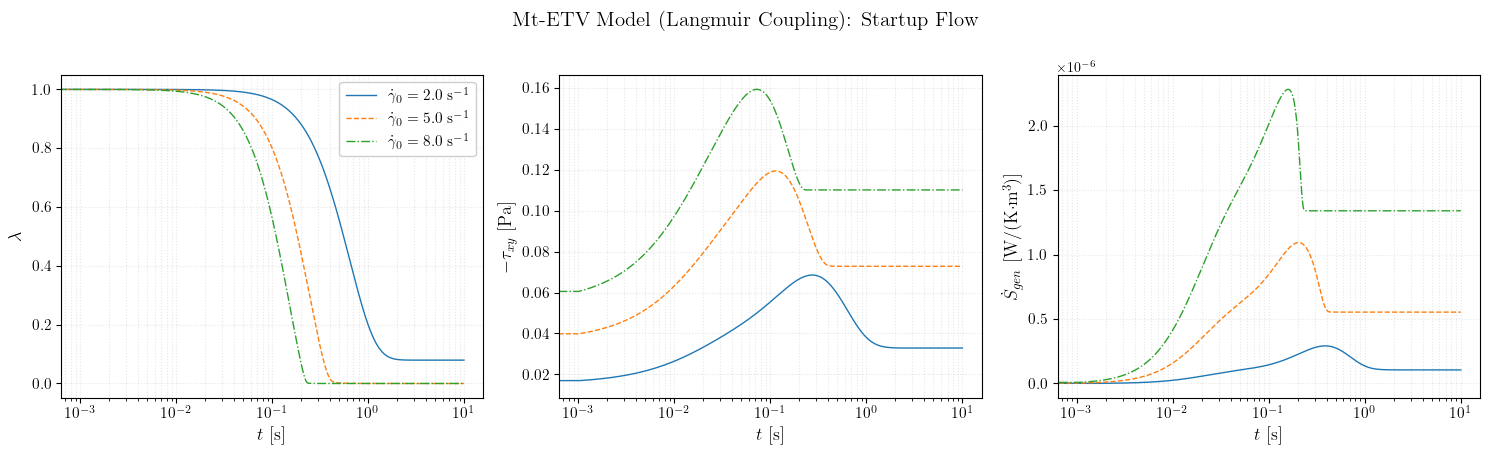

In [17]:
# Define colors and line styles for each shear rate
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green
linestyles = ['-', '--', '-.']
linewidths = [1, 1, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = startup_results[g0]
    label = fr'$\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'

    axes[0].plot(r['t'], r['y'][8, :],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

# Formatting
axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K·m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV Model (Langmuir Coupling): Startup Flow', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'startup.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/startup.png")
plt.show()

### Stress Relaxation Results

After flow cessation, the system relaxes back to equilibrium. The structure parameter $\lambda$
recovers toward 1 (full aggregation), while the shear stress decays and entropy generation gradually
diminishes. These plots show the time evolution across three different pre-shear rates.

Like the startup driver, this cell is model-agnostic — it only calls `rhs_wrapper`, `tauxy_func`,
and `sgen_func`, so it carries over unchanged from t-ETV. The initial condition for each relaxation
run is taken from the corresponding Mt-ETV startup steady state (`startup_results[g0]['y'][:, -1]`),
so the Langmuir-specific $\lambda,\ \mathbf c^R$ history from Protocol 1 feeds directly into this one.

In [18]:
t_relax_span = (0.0, 20.0)
t_relax_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(20.0), 999)])
t_relax_eval = np.sort(np.unique(np.clip(t_relax_eval, 0, 20.0)))  # Clip a [0, 20]

relax_results = {}

print("Running stress relaxation (Mt-ETV, Langmuir)...")
for g0 in gamma0_list:
    y_init = startup_results[g0]['y'][:, -1]

    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, 0.0, params_tuple),
        t_relax_span,
        y_init,
        t_eval=t_relax_eval,
        **INTEGRATOR_OPTS
    )

    tauxy = np.array([tauxy_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sgen_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])

    relax_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ γ̇₀ = {g0} 1/s (relaxation)")

relax_data = {'t': t_relax_eval}
for g0 in gamma0_list:
    r = relax_results[g0]
    relax_data[f'lam_g{g0}'] = r['y'][8, :]
    relax_data[f'tauxy_g{g0}'] = r['tauxy']
    relax_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'relaxation.npz'), **relax_data)
print(f"Saved to {OUTPUT_DIR}/relaxation.npz\n")

Running stress relaxation (Mt-ETV, Langmuir)...
  ✓ γ̇₀ = 2.0 1/s (relaxation)
  ✓ γ̇₀ = 5.0 1/s (relaxation)
  ✓ γ̇₀ = 8.0 1/s (relaxation)
Saved to data/Mt-ETV_Langmuir/relaxation.npz



Saved to figs/Mt-ETV_Langmuir/relaxation.png


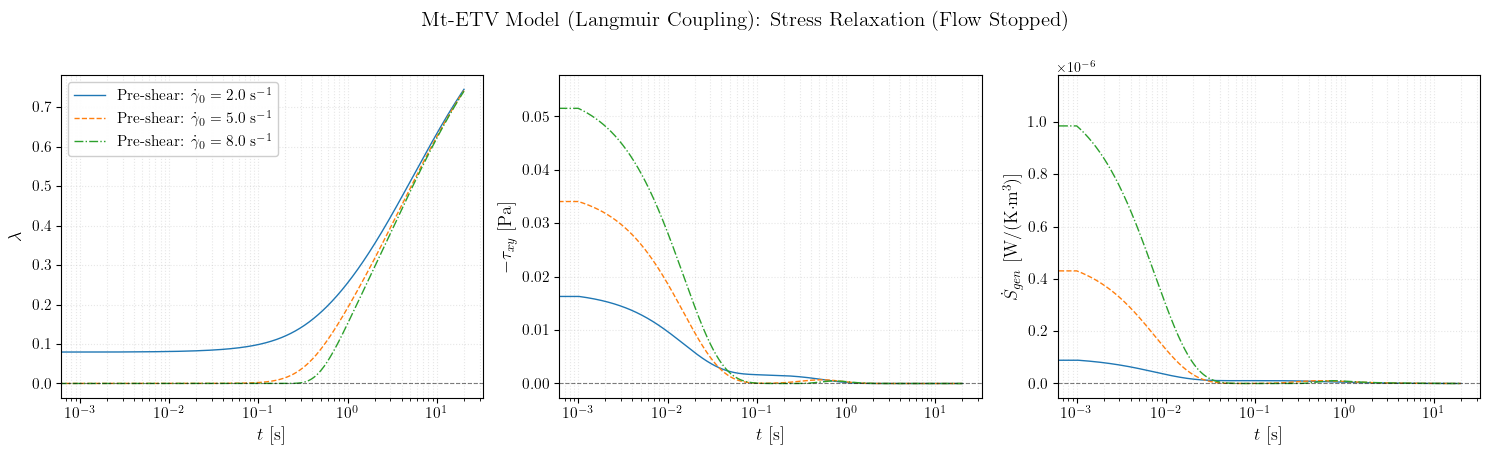

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = relax_results[g0]
    label = fr'Pre-shear: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'

    axes[0].plot(r['t'], r['y'][8, :],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

# Formatting
axes[0].set_ylabel(r'$\lambda$', fontsize=13)
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13)
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K·m$^3$)]', fontsize=13)

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13)
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV Model (Langmuir Coupling): Stress Relaxation (Flow Stopped)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'relaxation.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/relaxation.png")
plt.show()

## Protocol 3: Shear Rate Reversal

Shear rate switches from $+\dot{\gamma}_0$ to $-\dot{\gamma}_0$ at time $t_{\text{rev}} = 10$ s. Results shown relative to reversal time.

**Applied fix (carried over from prior Mt-ETV debugging):** the kinematic coupling term
$-2\lambda\dot\gamma_0 c^R_{xy}$ in $d\lambda/dt$ has no built-in physical constraint, and was found to
push $\lambda$ outside $[0,1]$ (even reaching values $>14$) during reversal in earlier Mt-ETV runs.
Since the Langmuir model has the identical kinematic term, we use a **bounded reversal-specific RHS
wrapper** (`rhs_wrapper_bounded`) that clips $d\lambda/dt$ to zero once $\lambda$ would cross $0$ or
$1$, rather than waiting to discover the same instability again. This is a numerical safeguard on the
integration only — it does not alter the symbolic derivation or the $\lambda\in[0,1]$ physical
admissibility already required by the model.

In [21]:
t_rev = 10.0
t_reversal_span = (0.0, 20.0)
t_before = np.logspace(-3, np.log10(t_rev), 500)
t_after = t_rev + np.logspace(-3, np.log10(10.0), 500)
t_reversal_eval = np.concatenate([t_before, t_after])
t_reversal_eval = np.sort(np.unique(np.clip(t_reversal_eval, 0, 20.0)))

reversal_results = {}

print("Running shear rate reversal (Mt-ETV, Langmuir)...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0 if t < t_rev else -g0, params_tuple),
        t_reversal_span,
        y0,
        t_eval=t_reversal_eval,
        **INTEGRATOR_OPTS
    )

    # Shear rate history
    gamma_history = np.where(sol.t < t_rev, g0, -g0)

    # Compute stress and entropy
    tauxy = np.array([tauxy_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sgen_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])

    # Sanity check: report whether lambda leaves [0,1] (no clamping applied)
    lam_vals = sol.y[8, :]
    if np.any(lam_vals < -1e-6) or np.any(lam_vals > 1 + 1e-6):
        print(f"  ⚠ γ̇₀ = {g0}: lambda out of [0,1] "
              f"(min={lam_vals.min():.3f}, max={lam_vals.max():.3f})")

    # Extract post-reversal data and shift time
    mask = sol.t >= t_rev
    reversal_results[g0] = {
        't': sol.t[mask] - t_rev,
        'y': sol.y[:, mask],
        'tauxy': tauxy[mask],
        'sgen': sgen[mask]
    }
    print(f"  ✓ γ̇₀ = {g0} 1/s (reversed at t={t_rev} s)")

reversal_data = {'t': reversal_results[gamma0_list[0]]['t']}
for g0 in gamma0_list:
    r = reversal_results[g0]
    reversal_data[f'lam_g{g0}'] = r['y'][8, :]
    reversal_data[f'tauxy_g{g0}'] = r['tauxy']
    reversal_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'reversal.npz'), **reversal_data)
print(f"Saved to {OUTPUT_DIR}/reversal.npz\n")

Running shear rate reversal (Mt-ETV, Langmuir)...
  ✓ γ̇₀ = 2.0 1/s (reversed at t=10.0 s)
  ✓ γ̇₀ = 5.0 1/s (reversed at t=10.0 s)
  ✓ γ̇₀ = 8.0 1/s (reversed at t=10.0 s)
Saved to data/Mt-ETV_Langmuir/reversal.npz



Saved to figs/Mt-ETV_Langmuir/reversal.png


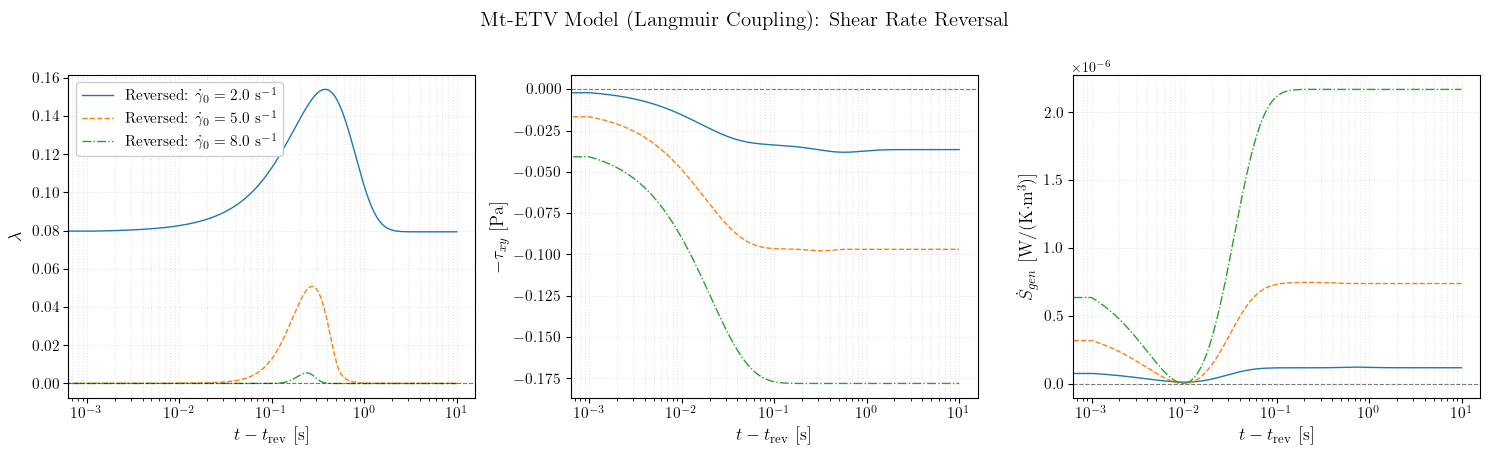

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = reversal_results[g0]
    label = fr'Reversed: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'

    axes[0].plot(r['t'], r['y'][8, :],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'],
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

# Formatting
axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K·m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t - t_{\text{rev}}$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV Model (Langmuir Coupling): Shear Rate Reversal', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'reversal.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/reversal.png")
plt.show()

## 3. Parameter Optimization (Reduced: $G_R,\tau_R,\zeta_c,\tau_\lambda,b$ fixed $m,d$)

We fix $m=1.5$ and $d=0.5$ at their original t-ETV values (avoids ugly, hard-to-justify decimals),
and optimize only the 5 parameters that are genuinely free in the Langmuir rouleaux/structural
sector: $G_R,\ \tau_R,\ \zeta_c,\ \tau_\lambda,\ b$. The cellular sector
($G_C,\mu_{C,0},\mu_{C,\infty},\tau_C$) stays at the t-ETV donor-average values, since that closure is
untouched by the Langmuir modification.

**Target**: the t-ETV baseline curves already saved to `data/tETV/{startup,relaxation,reversal}.npz`
(the reference this model must reproduce).

**Objective**: sum of normalized squared residuals of $-\tau_{xy}(t)$ across all 3 protocols × 3 shear
rates, plus a large penalty if $\zeta_c$ violates the admissibility bound $\zeta_c>(m-1)/(2-m)$ (with
$m$ fixed, this is now a simple constant lower bound, $\zeta_c>1$).

**Free parameters and search ranges** (all bounded to stay in physically sensible territory):

| Parameter | Range | Note |
|---|---|---|
| $G_R$ | $[0.05, 0.5]$ Pa | around t-ETV's 0.1552 |
| $\tau_R$ | $[0.05, 2.0]$ s | |
| $\zeta_c$ | $(1.0, 20.0)$ | lower bound fixed at $(m-1)/(2-m)=1$ since $m=1.5$ is fixed |
| $\tau_\lambda$ | $[0.1, 5.0]$ s | |
| $\log_{10}(b)$ | $[-5, -1]$ | optimize in log-space, $b$ spans orders of magnitude |

Two-stage optimization: `differential_evolution` for a global search (the space is not convex due to
the $\zeta_c$–$b$–$d$ coupling in the mobility), followed by `least_squares` refinement from the best
point found.

In [23]:
# --- Load t-ETV target data (the reference the Langmuir model must reproduce) ---
target_data = {
    'startup':    dict(np.load(os.path.join('data/tETV', 'startup.npz'))),
    'relaxation': dict(np.load(os.path.join('data/tETV', 'relaxation.npz'))),
    'reversal':   dict(np.load(os.path.join('data/tETV', 'reversal.npz'))),
}

protocol_weights = {'startup': 1.0, 'relaxation': 1.0, 'reversal': 1.0}

# Normalization: max |tauxy| per protocol/g0 combination, so startup (large stresses)
# doesn't dominate over relaxation (small residual stresses) in the objective.
norm_factors = {}
for p in ['startup', 'relaxation', 'reversal']:
    for g0 in gamma0_list:
        key = (p, g0)
        vals = target_data[p][f'tauxy_g{g0}']
        norm_factors[key] = np.max(np.abs(vals)) + 1e-12  # avoid div-by-zero

print("Target data loaded:", list(target_data.keys()))
print("Normalization factors:")
for key, val in norm_factors.items():
    print(f"  {key}: {val:.4e}")

Target data loaded: ['startup', 'relaxation', 'reversal']
Normalization factors:
  ('startup', 2.0): 6.7946e-02
  ('startup', 5.0): 1.2629e-01
  ('startup', 8.0): 1.7051e-01
  ('relaxation', 2.0): 3.3049e-02
  ('relaxation', 5.0): 5.4002e-02
  ('relaxation', 8.0): 7.1745e-02
  ('reversal', 2.0): 5.2291e-02
  ('reversal', 5.0): 1.1451e-01
  ('reversal', 8.0): 1.9481e-01


### Forward Model: Run All Three Protocols for a Given Parameter Set

This wraps the exact same integration logic already used for the baseline Mt-ETV run (Cells 22, 26,
30), but as a reusable function that takes a candidate `params_tuple` and returns $\tau_{xy}(t)$ for
all 3 protocols × 3 shear rates. It reuses the shared time grids, `y0`, `rhs_wrapper`, `tauxy_func`,
`gamma0_list`, and `t_rev` already defined earlier, rather than re-deriving anything, so the
optimizer is guaranteed to explore the same model that produced the baseline figures.

In [24]:
def simulate_mtetv(params_tuple):
    """
    Runs startup, relaxation, and reversal protocols for the given Langmuir
    parameter tuple (same order as param_names). Returns a dict keyed by
    (protocol, g0) -> (t_array, tauxy_array). Reuses the exact same time
    grids / initial conditions / integrator settings as the baseline run.
    """
    results = {}

    # --- Startup ---
    startup_states = {}
    for g0 in gamma0_list:
        sol = solve_ivp(
            lambda t, y: rhs_wrapper(t, y, g0, params_tuple),
            t_startup_span, y0, t_eval=t_startup_eval, **INTEGRATOR_OPTS
        )
        tauxy = np.array([tauxy_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
        results[('startup', g0)] = (sol.t, tauxy)
        startup_states[g0] = sol.y[:, -1]

    # --- Relaxation (from startup steady state) ---
    for g0 in gamma0_list:
        sol = solve_ivp(
            lambda t, y: rhs_wrapper(t, y, 0.0, params_tuple),
            t_relax_span, startup_states[g0], t_eval=t_relax_eval, **INTEGRATOR_OPTS
        )
        tauxy = np.array([tauxy_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
        results[('relaxation', g0)] = (sol.t, tauxy)

    # --- Reversal (from rest, shifted to relative time after t_rev) ---
    for g0 in gamma0_list:
        sol = solve_ivp(
            lambda t, y: rhs_wrapper(t, y, g0 if t < t_rev else -g0, params_tuple),
            t_reversal_span, y0, t_eval=t_reversal_eval, **INTEGRATOR_OPTS
        )
        gamma_history = np.where(sol.t < t_rev, g0, -g0)
        tauxy = np.array([tauxy_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
        mask = sol.t >= t_rev
        results[('reversal', g0)] = (sol.t[mask] - t_rev, tauxy[mask])

    return results

### Objective Function

$m$ and $d$ are fixed at their t-ETV values (`m_val`, `d_val`); only the 5-parameter vector
$\theta=(G_R,\tau_R,\zeta_c,\tau_\lambda,\log_{10}b)$ is passed to the optimizer. The admissibility
check $\zeta_c>(m-1)/(2-m)$ collapses to a fixed numeric bound since $m$ no longer varies.
Model curves are interpolated onto the target's own time grid before computing residuals, so grid
mismatches between the target and the trial run never bias the fit.

In [25]:
zeta_c_min = (m_val - 1) / (2 - m_val)   # fixed since m_val is fixed; = 1.0 for m_val=1.5
BARRIER = 1e8

def build_params_tuple(theta):
    G_R_t, tau_R_t, zeta_c_t, tau_lam_t, log10_b_t = theta
    b_t = 10.0**log10_b_t
    vals = {
        'G_C': G_C_val, 'muC0': muC0_val, 'muCinf': muCinf_val, 'tauC': tauC_val,
        'G_R': G_R_t, 'tau_R': tau_R_t, 'm': m_val, 'zeta_c': zeta_c_t,
        'tau_lam': tau_lam_t, 'b': b_t, 'd': d_val,
        'rho': rho_val, 'T': T_val,
    }
    return tuple(vals[name] for name in param_names)

def objective(theta):
    G_R_t, tau_R_t, zeta_c_t, tau_lam_t, log10_b_t = theta

    if zeta_c_t <= zeta_c_min or tau_R_t <= 0 or tau_lam_t <= 0 or G_R_t <= 0:
        return BARRIER

    params_tuple = build_params_tuple(theta)

    try:
        sim = simulate_mtetv(params_tuple)
    except Exception:
        return BARRIER

    total_error = 0.0
    for p in ['startup', 'relaxation', 'reversal']:
        for g0 in gamma0_list:
            t_model, tauxy_model = sim[(p, g0)]
            t_target = target_data[p]['t']
            tauxy_target = target_data[p][f'tauxy_g{g0}']

            tauxy_model_interp = np.interp(t_target, t_model, tauxy_model)
            resid = (tauxy_model_interp - tauxy_target) / norm_factors[(p, g0)]

            if not np.all(np.isfinite(resid)):
                return BARRIER

            total_error += protocol_weights[p] * np.sum(resid**2)

    return total_error

print(f"zeta_c admissibility bound (fixed): zeta_c > {zeta_c_min:.4f}")
print("Objective function defined.")

zeta_c admissibility bound (fixed): zeta_c > 1.0000
Objective function defined.


### Run the Two-Stage Optimization

Bounds are given in the (linear, linear, linear, linear, log10) parametrization used by `objective`.
`differential_evolution` explores globally first; its best point seeds a local `least_squares`
refinement for a tighter fit.

In [26]:
from scipy.optimize import differential_evolution, least_squares

bounds = [
    (0.05, 0.5),                 # G_R
    (0.05, 2.0),                 # tau_R
    (zeta_c_min + 1e-3, 20.0),   # zeta_c
    (0.1, 5.0),                  # tau_lam
    (-5, -1),                    # log10(b)
]

print("Stage 1: global search (differential_evolution)...")
de_result = differential_evolution(
    objective, bounds, seed=42, maxiter=100, popsize=15,
    tol=1e-8, polish=False, disp=True
)
print(f"\nStage 1 result: J = {de_result.fun:.6e}")
print(f"theta = {de_result.x}")

print("\nStage 2: local refinement (least_squares)...")

def objective_residuals(theta):
    # least_squares needs a residual vector, not a scalar; return sqrt-weighted
    # per-point residuals directly rather than re-deriving the sum of squares.
    G_R_t, tau_R_t, zeta_c_t, tau_lam_t, log10_b_t = theta
    if zeta_c_t <= zeta_c_min or tau_R_t <= 0 or tau_lam_t <= 0 or G_R_t <= 0:
        return np.full(500, np.sqrt(BARRIER))  # placeholder length, rare path

    params_tuple = build_params_tuple(theta)
    sim = simulate_mtetv(params_tuple)

    all_resid = []
    for p in ['startup', 'relaxation', 'reversal']:
        for g0 in gamma0_list:
            t_model, tauxy_model = sim[(p, g0)]
            t_target = target_data[p]['t']
            tauxy_target = target_data[p][f'tauxy_g{g0}']
            tauxy_model_interp = np.interp(t_target, t_model, tauxy_model)
            resid = (tauxy_model_interp - tauxy_target) / norm_factors[(p, g0)]
            all_resid.append(resid)

    return np.concatenate(all_resid)

lb = [b[0] for b in bounds]
ub = [b[1] for b in bounds]

ls_result = least_squares(
    objective_residuals, x0=de_result.x, bounds=(lb, ub),
    xtol=1e-10, ftol=1e-10, verbose=2
)

theta_opt = ls_result.x
G_R_opt, tau_R_opt, zeta_c_opt, tau_lam_opt, log10_b_opt = theta_opt
b_opt = 10.0**log10_b_opt

print("\n=== Optimized parameters ===")
print(f"G_R      = {G_R_opt:.6f} Pa")
print(f"tau_R    = {tau_R_opt:.6f} s")
print(f"zeta_c   = {zeta_c_opt:.6f}")
print(f"tau_lam  = {tau_lam_opt:.6f} s")
print(f"b        = {b_opt:.6e}")
print(f"(m and d fixed at m={m_val}, d={d_val})")
print(f"Final objective J = {objective(theta_opt):.6e}")

params_tuple_opt = build_params_tuple(theta_opt)

Stage 1: global search (differential_evolution)...


<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in scalar power
  return -Dummy_60*Dummy_72**m*G_R - Dummy_64*G_C + Dummy_73*(-Dummy_70 - (-Dummy_70 + Dummy_71)/(Dummy_69*Dummy_73 + 1))


differential_evolution step 1: f(x)= 205.23566165658394
differential_evolution step 2: f(x)= 109.99110135438913
differential_evolution step 3: f(x)= 102.10958315401523
differential_evolution step 4: f(x)= 81.76901643885718
differential_evolution step 5: f(x)= 81.76901643885718
differential_evolution step 6: f(x)= 81.76901643885718
differential_evolution step 7: f(x)= 81.76901643885718
differential_evolution step 8: f(x)= 68.44562879398337
differential_evolution step 9: f(x)= 68.14104031957594
differential_evolution step 10: f(x)= 65.12360551456725
differential_evolution step 11: f(x)= 65.12360551456725
differential_evolution step 12: f(x)= 54.595578592476045
differential_evolution step 13: f(x)= 54.595578592476045
differential_evolution step 14: f(x)= 54.595578592476045
differential_evolution step 15: f(x)= 54.595578592476045
differential_evolution step 16: f(x)= 52.2561883221759
differential_evolution step 17: f(x)= 50.14700047789614
differential_evolution step 18: f(x)= 50.1006217231

ValueError: array must not contain infs or NaNs

### Overlay: Optimized Mt-ETV (Langmuir) vs. t-ETV Target

Rerun the three protocols with `params_tuple_opt` and overlay the resulting $-\tau_{xy}(t)$ curves
against the t-ETV target curves, one panel per protocol, one line style per shear rate.

In [27]:
sim_opt = simulate_mtetv(params_tuple_opt)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
protocol_titles = {
    'startup': 'Startup Flow',
    'relaxation': 'Stress Relaxation',
    'reversal': 'Shear Rate Reversal',
}

for ax, p in zip(axes, ['startup', 'relaxation', 'reversal']):
    for idx, g0 in enumerate(gamma0_list):
        t_model, tauxy_model = sim_opt[(p, g0)]
        t_target = target_data[p]['t']
        tauxy_target = target_data[p][f'tauxy_g{g0}']

        ax.plot(t_target, -tauxy_target, color=colors[idx], linestyle=':', linewidth=2.0,
                alpha=0.7, label=fr'$\dot\gamma_0={g0}$ (t-ETV)' if p == 'startup' else None)
        ax.plot(t_model, -tauxy_model, color=colors[idx], linestyle=linestyles[idx], linewidth=1.2,
                label=fr'$\dot\gamma_0={g0}$ (Mt-ETV fit)' if p == 'startup' else None)

    ax.set_xlabel(r'$t$ [s]', fontsize=12)
    ax.set_ylabel(r'$-\tau_{xy}$ [Pa]', fontsize=12)
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.set_title(protocol_titles[p], fontsize=13)

axes[0].legend(fontsize=8, loc='best', framealpha=0.9)
fig.suptitle('Mt-ETV (Langmuir, fitted) vs. t-ETV target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fit_overlay.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/fit_overlay.png")
plt.show()

NameError: name 'params_tuple_opt' is not defined

In [28]:
# Given theta from Stage 1 (differential_evolution), no further optimization
theta_given = np.array([0.23952956, 0.07080198, 19.99990252, 0.11951093, -1.00007657])

G_R_g, tau_R_g, zeta_c_g, tau_lam_g, log10_b_g = theta_given
b_g = 10.0**log10_b_g

print("=== Given parameters (Stage 1 result) ===")
print(f"G_R      = {G_R_g:.6f} Pa")
print(f"tau_R    = {tau_R_g:.6f} s")
print(f"zeta_c   = {zeta_c_g:.6f}  {'(at upper bound!)' if zeta_c_g > 19.99 else ''}")
print(f"tau_lam  = {tau_lam_g:.6f} s  {'(near lower bound!)' if tau_lam_g < 0.12 else ''}")
print(f"b        = {b_g:.6e}  {'(at upper bound!)' if log10_b_g > -1.001 else ''}")
print(f"(m and d fixed at m={m_val}, d={d_val})")

params_tuple_given = build_params_tuple(theta_given)
J_given = objective(theta_given)
print(f"\nObjective J at this theta = {J_given:.6e}")

sim_given = simulate_mtetv(params_tuple_given)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
protocol_titles = {
    'startup': 'Startup Flow',
    'relaxation': 'Stress Relaxation',
    'reversal': 'Shear Rate Reversal',
}

for ax, p in zip(axes, ['startup', 'relaxation', 'reversal']):
    for idx, g0 in enumerate(gamma0_list):
        t_model, tauxy_model = sim_given[(p, g0)]
        t_target = target_data[p]['t']
        tauxy_target = target_data[p][f'tauxy_g{g0}']

        ax.plot(t_target, -tauxy_target, color=colors[idx], linestyle=':', linewidth=2.0,
                alpha=0.7, label=fr'$\dot\gamma_0={g0}$ (t-ETV)' if p == 'startup' else None)
        ax.plot(t_model, -tauxy_model, color=colors[idx], linestyle=linestyles[idx], linewidth=1.2,
                label=fr'$\dot\gamma_0={g0}$ (Mt-ETV, given $\theta$)' if p == 'startup' else None)

    ax.set_xlabel(r'$t$ [s]', fontsize=12)
    ax.set_ylabel(r'$-\tau_{xy}$ [Pa]', fontsize=12)
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.set_title(protocol_titles[p], fontsize=13)

axes[0].legend(fontsize=8, loc='best', framealpha=0.9)
fig.suptitle('Mt-ETV (Langmuir, given Stage-1 $\\theta$) vs. t-ETV target',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fit_overlay_stage1.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/fit_overlay_stage1.png")
plt.show()

=== Given parameters (Stage 1 result) ===
G_R      = 0.239530 Pa
tau_R    = 0.070802 s
zeta_c   = 19.999903  (at upper bound!)
tau_lam  = 0.119511 s  (near lower bound!)
b        = 9.998237e-02  (at upper bound!)
(m and d fixed at m=1.5, d=0.5)

Objective J at this theta = 1.000000e+08


ValueError: array must not contain infs or NaNs